In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/AmesHousing.csv')

# Log transform the target variable
df['SalePrice_log'] = np.log1p(df['SalePrice'])

print("Shape:", df.shape)

Shape: (2930, 83)


In [4]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

# For numeric columns - fill missing with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# For categorical colums - fill missing with most frequent value
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify
print("Any missing values left:", df.isnull().sum().sum())

Any missing values left: 0


In [6]:
# Total squarevfootage (basement + first floor + second floor)
df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']

# Total number of bathrooms
df['TotalBaths'] = (df['Full Bath'] +
                    df['Half Bath'] * 0.5 +
                    df['Bsmt Full Bath'] + 
                    df['Bsmt Half Bath'] * 0.5)

# Age of house when sold
df['HouseAge'] = df['Yr Sold'] - df['Year Built']

# Years since last remodel
df['YearsSinceRemodel'] = df['Yr Sold'] - df['Year Remod/Add']

# Has pool (binary yes/no)
df['HasPool'] = (df['Pool Area'] > 0).astype(int)

# Has garage (binary yes/no)
df['HasGarage'] = (df['Garage Area'] > 0).astype(int)

# Has basement (binary yes/no)
df['HasBasement'] = (df['Total Bsmt SF'] > 0).astype(int)

print("New features added:")
print(df[['TotalSF', 'TotalBaths', 'HouseAge', 'YearsSinceRemodel', 'HasPool',
            'HasGarage', 'HasBasement']].head())

New features added:
   TotalSF  TotalBaths  HouseAge  YearsSinceRemodel  HasPool  HasGarage  \
0   2736.0         2.0        50                 50        0          1   
1   1778.0         1.0        49                 49        0          1   
2   2658.0         1.5        52                 52        0          1   
3   4220.0         3.5        42                 42        0          1   
4   2557.0         2.5        13                 12        0          1   

   HasBasement  
0            1  
1            1  
2            1  
3            1  
4            1  


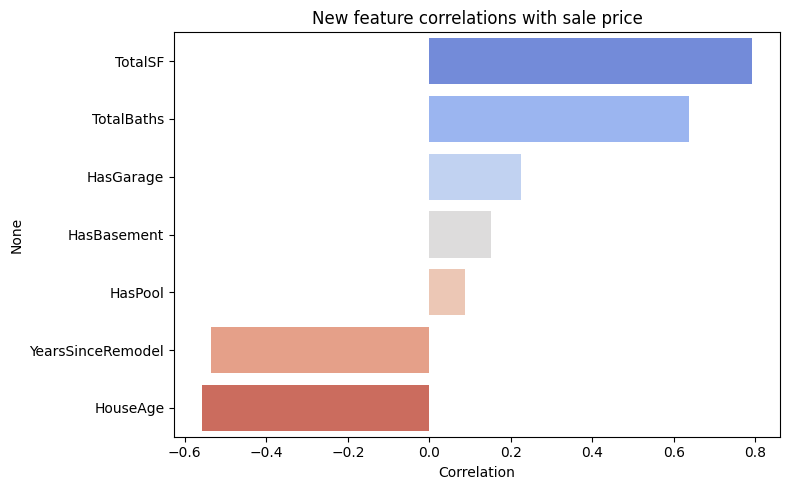

TotalSF              0.793071
TotalBaths           0.636175
HasGarage            0.225950
HasBasement          0.152630
HasPool              0.087960
YearsSinceRemodel   -0.534940
HouseAge            -0.558907
Name: SalePrice, dtype: float64


In [9]:
new_features = ['TotalSF', 'TotalBaths', 'HouseAge', 'YearsSinceRemodel',
                'HasPool', 'HasGarage', 'HasBasement']

correlations = df[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
correlations = correlations.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=correlations.values, y=correlations.index, 
            hue=correlations.index, palette='coolwarm', legend=False)
plt.title('New feature correlations with sale price')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('../visuals/03_feature_correlations.png', dpi=150)
plt.show()

print(correlations)

In [12]:
# These are the features we'll feed into the model
# Mix of original strong features + our engineered one
features = [
    # Original strong features
    'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area',
    'Total Bsmt SF', 'Year Built', 'Full Bath', 'TotRms AbvGrd',
    # Our engineered features
    'TotalSF', 'TotalBaths', 'HouseAge', 'YearsSinceRemodel',
    'HasGarage', 'HasBasement'
]

X = df[features]
y = df['SalePrice_log']

print("Features shape:", X.shape)
print("Target shape", y.shape)
print("\nAny missing values in features:", X.isnull().sum().sum())

Features shape: (2930, 14)
Target shape (2930,)

Any missing values in features: 0
